# Section: Robust Value Iteration (Model-Based Safe RL)


In [ ]:

import gymnasium as gym
import highway_env
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import namedtuple

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import trange
from pathlib import Path

class NoisyObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_std=0.2):
        super(NoisyObservationWrapper, self).__init__(env)
        self.noise_std = noise_std

    def observation(self, obs):
        noise = np.random.normal(0, self.noise_std, obs.shape)
        return obs + noise

from highway_env.envs import roundabout_env
import gym


base_env = roundabout_env.RoundaboutEnv()
base_env.configure({
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 5,
        "features": ["presence", "x", "y", "vx", "vy"],
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-20, 20],
            "vy": [-20, 20]
        }
    },
    "duration": 40,
    "simulation_frequency": 15,
    "policy_frequency": 5,
    "render_mode": "rgb_array"
})


env = NoisyObservationWrapper(base_env, noise_std=0.2)
env.reset()



(array([[ 0.95411787,  0.10986734,  0.55564074,  0.08659345,  0.05167726],
        [ 0.97450587, -0.27158064, -0.49462674,  0.6475552 ,  0.76425696],
        [ 1.05552961, -0.0640398 ,  0.13318893,  0.13764543,  1.04660295],
        [ 0.82168299,  1.24795109,  0.01847226, -0.63323076,  0.10564837],
        [ 0.98098139, -0.38990557, -0.90539955, -0.52711717,  0.92477773]]),
 {'speed': 8,
  'crashed': False,
  'action': np.int64(2),
  'rewards': {'collision_reward': False,
   'high_speed_reward': np.float64(0.5),
   'lane_change_reward': True,
   'on_road_reward': np.True_}})

## Collect Rollouts/ Cluster States

In [ ]:
def flatten_obs(obs):
    if isinstance(obs, dict):
        obs = obs["observation"] if "observation" in obs else list(obs.values())[0]
    return np.array(obs).flatten()

from tqdm import trange

def collect_rollouts(env, num_episodes=100, max_steps=100):
    states, actions, next_states, rewards, dones = [], [], [], [], []

    for episode in trange(num_episodes, desc="Collecting rollouts"):
        obs, _ = env.reset()  # ← updated unpack
        obs = flatten_obs(obs)

        for _ in range(max_steps):
            action = env.action_space.sample()
            next_obs, reward, done, truncated, _ = env.step(action)
            next_obs = flatten_obs(next_obs)

            states.append(obs)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_obs)
            dones.append(done or truncated)

            obs = next_obs
            if done or truncated:
                break

    return np.array(states), np.array(actions), np.array(next_states), np.array(rewards), np.array(dones)

def cluster_states(states, n_clusters=50):
    flat_states = states.reshape(states.shape[0], -1)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(flat_states)
    return labels, kmeans


## Transtion and Rewards Estimator

In [ ]:
def estimate_transition_and_rewards(clustered_states, actions, next_states, rewards, kmeans, num_clusters=50):
    P = np.zeros((num_clusters, env.action_space.n, num_clusters))
    R = np.zeros((num_clusters, env.action_space.n))

    for s_idx, a, next_s, r in zip(clustered_states, actions, next_states, rewards):
        s_next_idx = kmeans.predict(next_s.reshape(1, -1))[0]
        P[s_idx, a, s_next_idx] += 1
        R[s_idx, a] += r

    for s in range(num_clusters):
        for a in range(env.action_space.n):
            if np.sum(P[s, a]) > 0:
                P[s, a] /= np.sum(P[s, a])
                R[s, a] /= np.sum(P[s, a] > 0)
    return P, R


## Robust Value Iteration Model

In [ ]:
def robust_value_iteration(states, actions, P_env, R, gamma=0.9, epsilon=1e-3, beta=0.05):
    V = np.zeros(len(states))
    policy = np.zeros(len(states), dtype=int)

    while True:
        delta = 0
        for s in range(len(states)):
            worst_case_values = []
            for a in range(len(actions)):
                p_sa = P_env[s][a]
                adversarial_p = np.clip(p_sa - beta, 0, 1)
                if np.sum(adversarial_p) > 0:
                    adversarial_p /= np.sum(adversarial_p)
                q_sa = R[s][a] + gamma * np.sum(adversarial_p * V)
                worst_case_values.append(q_sa)

            best_value = max(worst_case_values)
            best_action = np.argmax(worst_case_values)

            delta = max(delta, abs(best_value - V[s]))
            V[s] = best_value
            policy[s] = best_action

        if delta < epsilon:
            break
    return V, policy


In [ ]:
states, actions, next_states, rewards, dones = collect_rollouts(env, num_episodes=20)
clustered_states, kmeans = cluster_states(states, n_clusters=50)
P_est, R_est = estimate_transition_and_rewards(clustered_states, actions, next_states, rewards, kmeans)
V, policy = robust_value_iteration(list(range(50)), list(range(env.action_space.n)), P_est, R_est)


## Evaluation of RVI

In [ ]:
from tqdm import tqdm
import numpy as np

def evaluate_policy(env, kmeans, policy, episodes=20):
    total_rewards = []

    for _ in tqdm(range(episodes), desc="Evaluating policy"):
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        obs = flatten_obs(obs)
        done = False
        total_reward = 0

        while not done:
            cluster = kmeans.predict(obs.reshape(1, -1))[0]
            action = policy[cluster]

            step_result = env.step(action)
            if len(step_result) == 5:
                next_obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated
            else:
                next_obs, reward, done, _ = step_result

            obs = flatten_obs(next_obs)
            total_reward += reward

        total_rewards.append(total_reward)

    print("Average Policy Reward:", np.mean(total_rewards))
    return total_rewards


rewards_fixed = evaluate_policy(env, kmeans, policy)

Evaluating policy: 100%|██████████| 20/20 [04:22<00:00, 13.11s/it]

Average Policy Reward: 86.64166666666662


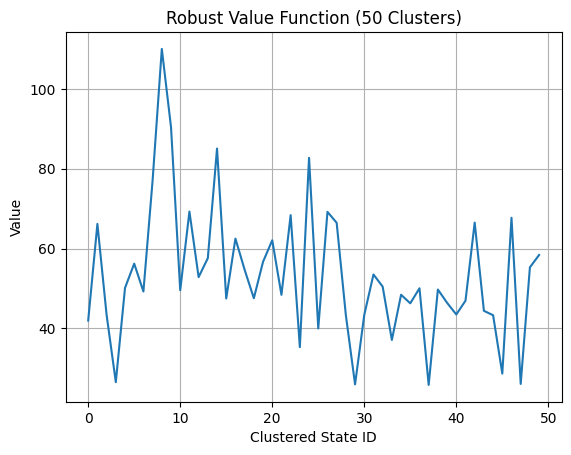

In [ ]:
plt.plot(V)
plt.title("Robust Value Function (50 Clusters)")
plt.xlabel("Clustered State ID")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## Video Display

In [ ]:
!pip install imageio[ffmpeg] moviepy --quiet


In [ ]:
import base64
import glob
from IPython.display import HTML

def show_videos(path="./video"):
    mp4list = glob.glob(f"{path}/*.mp4")
    if len(mp4list) == 0:
        print("No video found")
        return
    mp4 = mp4list[0]
    video_encoded = base64.b64encode(open(mp4, 'rb').read()).decode('ascii')
    return HTML(f"""
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{video_encoded}" type="video/mp4">
        </video>
    """)


In [ ]:
from gym.wrappers import RecordVideo
from highway_env.envs import roundabout_env
base_env = roundabout_env.RoundaboutEnv()
base_env.configure({
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 5,
        "features": ["presence", "x", "y", "vx", "vy"],
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-20, 20],
            "vy": [-20, 20]
        }
    },
    "duration": 40,
    "simulation_frequency": 15,
    "policy_frequency": 5
})
base_env.render_mode = "rgb_array"
env = NoisyObservationWrapper(base_env, noise_std=0.2)
video_folder = "./video"
env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda episode_id: True)
obs, _ = env.reset()
obs = flatten_obs(obs)

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
obs, _ = env.reset()
obs = flatten_obs(obs)
done = False
step = 0
max_steps = 100

while not done and step < max_steps:
    cluster = kmeans.predict(obs.reshape(1, -1))[0]
    action = policy[cluster]
    obs, reward, done, info = env.step(action)
    obs = flatten_obs(obs)
    step += 1

env.close()


show_videos()



## Robust Value Iteration with Adaptive Beta Estimator

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def estimate_state_uncertainty(clustered_states, actions, next_states, kmeans, num_clusters=50):
    X = np.column_stack([clustered_states, actions])
    y = [kmeans.predict(ns.reshape(1, -1))[0] for ns in next_states]
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    cluster_errors = np.zeros(num_clusters)
    cluster_counts = np.zeros(num_clusters)
    for i, (true_c, pred_c) in enumerate(zip(y, y_pred)):
        cluster_errors[clustered_states[i]] += (true_c != pred_c)
        cluster_counts[clustered_states[i]] += 1
    avg_errors = np.divide(cluster_errors, cluster_counts, out=np.zeros_like(cluster_errors), where=cluster_counts!=0)
    max_beta = 0.1
    normalized_beta = (avg_errors - avg_errors.min()) / (avg_errors.max() - avg_errors.min() + 1e-8)
    beta_per_state = np.clip(normalized_beta * max_beta, 0, 0.1)

    return beta_per_state


In [63]:
def robust_value_iteration_adaptive_beta(states, actions, P_env, R, beta_vec, gamma=0.9, epsilon=1e-3):
    V = np.zeros(len(states))
    policy = np.zeros(len(states), dtype=int)

    while True:
        delta = 0
        for s in range(len(states)):
            worst_case_values = []
            beta = beta_vec[s]
            for a in range(len(actions)):
                p_sa = P_env[s][a]
                adversarial_p = np.clip(p_sa - beta, 0, 1)
                if np.sum(adversarial_p) > 0:
                    adversarial_p /= np.sum(adversarial_p)
                q_sa = R[s][a] + gamma * np.sum(adversarial_p * V)
                worst_case_values.append(q_sa)

            best_value = max(worst_case_values)
            best_action = np.argmax(worst_case_values)

            delta = max(delta, abs(best_value - V[s]))
            V[s] = best_value
            policy[s] = best_action

        if delta < epsilon:
            break
    return V, policy

In [64]:
from tqdm import trange

def collect_rollouts(env, num_episodes=100, max_steps=100):
    states, actions, next_states, rewards, dones = [], [], [], [], []

    for episode in trange(num_episodes, desc="Collecting rollouts"):
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        obs = flatten_obs(obs)
        cluster = kmeans.predict(obs.reshape(1, -1))[0]
        action = policy[cluster]


        for step in range(max_steps):
            action = env.action_space.sample()
            next_obs, reward, done, info = env.step(action)
            next_obs = flatten_obs(next_obs)

            states.append(obs)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_obs)
            dones.append(done)

            obs = next_obs
            if done:
                break

    return np.array(states), np.array(actions), np.array(next_states), np.array(rewards), np.array(dones)


In [65]:
states, actions, next_states, rewards, dones = collect_rollouts(env, num_episodes=20)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
states_scaled = scaler.fit_transform(states)
clustered_states, kmeans = cluster_states(states_scaled, n_clusters=50)
P_est, R_est = estimate_transition_and_rewards(clustered_states, actions, next_states, rewards, kmeans)
beta_vec = estimate_state_uncertainty(clustered_states, actions, next_states, kmeans)
V, policy = robust_value_iteration_adaptive_beta(list(range(50)), list(range(env.action_space.n)), P_est, R_est, beta_vec)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluation of RVI adaptive Beta

In [66]:
from tqdm import trange

def evaluate_policy(env, kmeans, policy, episodes=20):
    total_rewards = []

    for episode in trange(episodes, desc="Evaluating policy"):
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        obs = flatten_obs(obs)
        done = False
        total_reward = 0

        while not done:
            cluster = kmeans.predict(obs.reshape(1, -1))[0]
            action = policy[cluster]
            next_obs, reward, done, info = env.step(action)
            obs = flatten_obs(next_obs)
            total_reward += reward

            if done:
                break

        total_rewards.append(total_reward)

    print("Average Policy Reward:", np.mean(total_rewards))
    return total_rewards


In [67]:
rewards_adaptive = evaluate_policy(env, kmeans, policy)
print(rewards_adaptive)

Evaluating policy:  85%|████████▌ | 17/20 [05:25<01:02, 20.77s/it]/usr/local/lib/python3.11/dist-packages/highway_env/envs/common/observation.py:228: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature] = utils.lmap(df[feature], [f_range[0], f_range[1]], [-1, 1])
/usr/local/lib/python3.11/dist-packages/highway_env/envs/common/observation.py:230: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature] = np.clip(df[feature], -1, 1)
/usr/local/lib/python3.11/dist-packages/highway_env/envs/common/observa

Average Policy Reward: 132.38124999999997
[np.float64(76.20833333333337), np.float64(152.9583333333333), np.float64(15.458333333333332), np.float64(140.08333333333326), np.float64(165.29166666666674), np.float64(172.33333333333346), np.float64(174.79166666666674), np.float64(129.58333333333337), np.float64(133.16666666666666), np.float64(130.20833333333331), np.float64(129.24999999999986), np.float64(174.9166666666666), np.float64(171.54166666666677), np.float64(92.79166666666663), np.float64(101.24999999999991), np.float64(128.54166666666652), np.float64(148.87499999999997), np.float64(166.79166666666657), np.float64(134.83333333333323), np.float64(108.74999999999994)]


<ipython-input-68-fcf3d9d524a0>:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rewards_fixed, rewards_adaptive], labels=["Fixed β", "Adaptive β"])


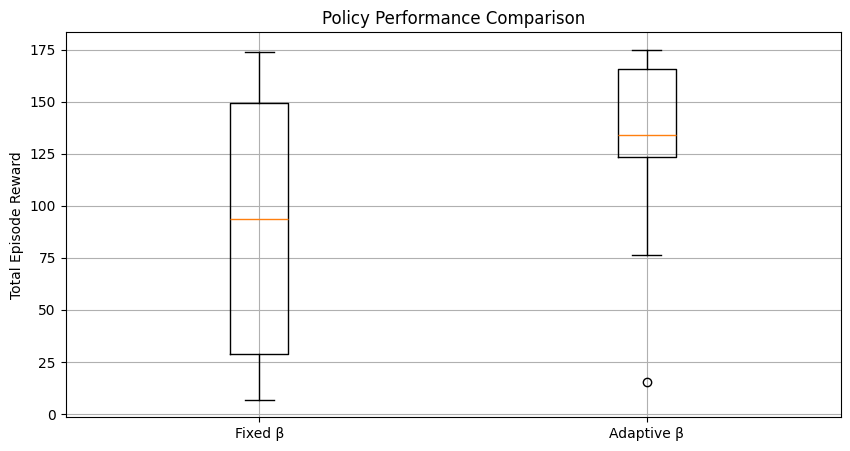

Fixed β Average Reward: 86.64166666666662
Adaptive β Average Reward: 132.38124999999997


In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.boxplot([rewards_fixed, rewards_adaptive], labels=["Fixed β", "Adaptive β"])
plt.ylabel("Total Episode Reward")
plt.title("Policy Performance Comparison")
plt.grid(True)
plt.show()

print("Fixed β Average Reward:", np.mean(rewards_fixed))
print("Adaptive β Average Reward:", np.mean(rewards_adaptive))

## Video of RVI Adaptive Beta

In [69]:
from gym.wrappers import RecordVideo
from highway_env.envs import roundabout_env
base_env = roundabout_env.RoundaboutEnv()
base_env.configure({
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 5,
        "features": ["presence", "x", "y", "vx", "vy"],
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-20, 20],
            "vy": [-20, 20]
        }
    },
    "duration": 40,
    "simulation_frequency": 15,
    "policy_frequency": 5
})
base_env.render_mode = "rgb_array"
env = NoisyObservationWrapper(base_env, noise_std=0.2)
video_folder = "./video"
env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda episode_id: True)
obs, _ = env.reset()
obs = flatten_obs(obs)

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [70]:
obs, _ = env.reset()
obs = flatten_obs(obs)
done = False
step = 0
max_steps = 100

while not done and step < max_steps:
    cluster = kmeans.predict(obs.reshape(1, -1))[0]
    action = policy[cluster]
    obs, reward, done, info = env.step(action)
    obs = flatten_obs(obs)
    step += 1

env.close()


show_videos()